# Bayesian Logistic Regression on the Farmingham Dataset

In [1]:
import pandas as pd
import torch
from torch import Tensor
from geodesic_toolbox.cometric import  BLRSoftAbs, BLRDualRanders
from geodesic_toolbox.samplers import ImplicitRHMCSampler, ImplicitFHMCUnbiased
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

## Importation of the dataset

In [2]:
file_path = "../data/framingham/framingham.csv"
df = pd.read_csv(file_path)
df = df.dropna()

df.head()


,RANDID,SEX,TOTCHOL,AGE,SYSBP,DIABP,CURSMOKE,CIGPDAY,BMI,DIABETES,...,CVD,HYPERTEN,TIMEAP,TIMEMI,TIMEMIFC,TIMECHD,TIMESTRK,TIMECVD,TIMEDTH,TIMEHYP
4,6238,2,237.0,58,108.0,66.0,0,0.0,28.50,0,...,0,0,8766,8766,8766,8766,8766,8766,8766,8766
14,11263,2,220.0,55,180.0,106.0,0,0.0,31.17,1,...,1,1,8766,8766,5719,5719,8766,5719,8766,0
19,12806,2,320.0,57,110.0,46.0,1,30.0,22.02,0,...,0,1,8766,8766,8766,8766,8766,8766,8766,8679
22,14367,1,280.0,64,168.0,100.0,0,0.0,25.72,0,...,0,1,8766,8766,8766,8766,8766,8766,8766,0
25,16365,1,211.0,55,173.0,123.0,0,0.0,29.11,0,...,0,1,8766,8766,8766,8766,8766,8766,8766,0


In [3]:
cols_to_drop = [
    'RANDID', 'PERIOD',
    'DEATH', 'ANGINA', 'HOSPMI', 'MI_FCHD', 'STROKE', 'CVD', 'HYPERTEN',
    'TIME', 'TIMECHD', 'TIMECVD', 'TIMEDTH', 'TIMEHYP',
    'TIMEAP', 'TIMEMI', 'TIMEMIFC', 'TIMESTRK'
]

X = df.drop(columns=cols_to_drop + ['ANYCHD'])
y = df['ANYCHD']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test  = torch.tensor(y_test.values,  dtype=torch.float32)
X_train = torch.tensor(X_train,        dtype=torch.float32)
X_test  = torch.tensor(X_test,         dtype=torch.float32)

# Add bias column so features shape is (N, D+1) and beta shape is (B, D+1)
X_train = torch.cat([X_train, torch.ones(X_train.shape[0], 1)], dim=1)
X_test  = torch.cat([X_test,  torch.ones(X_test.shape[0],  1)], dim=1)

## Riemannian Hamiltonian Monte Carlo Sampling


### Definition of the sampler

In [4]:
class BLRRHMCImplicit(ImplicitRHMCSampler):
    def __init__(self, features : Tensor, labels : Tensor, l: int, N_fx: int, gamma: float, N_run: int, std_0: float = 1, bounds: float = 1000, beta_0: float = 1, pbar: bool = False, skip_acceptance: bool = False, threshold_fx: float = 0.00001, var : float = 1, alpha: float = 1.):
        self.features = features
        self.labels = labels
        self.var = var
        cometric = BLRSoftAbs(features, var, alpha)
        super().__init__(cometric, l, N_fx, gamma, N_run, std_0, bounds, beta_0, pbar, skip_acceptance, threshold_fx)

    def U(self, beta):
        # Log-likelihood terms
        lh_term = beta @ self.features.T @ self.labels - torch.sum(torch.log(1 + torch.exp(beta @ self.features.T)), axis = 1)
        # Prior term
        prior_term = -0.5/self.var*(beta**2).sum(dim=1)
        return -(lh_term + prior_term)

### Test

In [5]:
l = 1
N_fx = 6
gamma = 0.2
N_run = 1000

sampler = BLRRHMCImplicit(
    features= X_train, 
    labels = y_train,
    l = l, 
    N_fx= N_fx,
    gamma = gamma,
    N_run = N_run,
)

In [6]:
n_traj = 100
z_0 = torch.randn(n_traj, X_train.shape[1])  
traj_rhmc, acc_rhmc = sampler.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True
    )
print(f"Acceptance rate: {acc_rhmc:.4f}")

Sampling:   0%|          | 0/1000 [00:00<?, ?steps/s]

Sampling: 100%|██████████| 1000/1000 [06:48<00:00,  2.45steps/s, acceptance_rate=0.899]

Acceptance rate: 0.8995


In [7]:
burn_in = 100
beta_mean = traj_rhmc[:, burn_in:, :].mean(dim=1)  # (n_traj, D+1)
logits    = beta_mean @ X_test.T                    # (n_traj, N_test)
preds     = (torch.sigmoid(logits) > 0.5)           # (n_traj, N_test)
acc_per_traj = (preds == y_test.bool()).float().mean(dim=1)  # (n_traj,)
print(f"Mean accuracy: {acc_per_traj.mean():.4f} ± {acc_per_traj.std():.4f}")

Mean accuracy: 0.8066 ± 0.1092


## Finsler Randers Hamiltonian Monte Carlo Sampling

### Definition of the sampler

In [8]:
class BLRFHMCUnbiased(ImplicitFHMCUnbiased):
    def __init__(self, features: Tensor, labels: Tensor,
                 l: int, N_fx: int, gamma: float, N_run: int,
                 bounds: float = 1e3, std_0: float = 1., beta_0: float = 1.,
                 pbar: bool = False, skip_acceptance: bool = False,
                 reduced_flip: bool = True,
                 var: float = 1., alpha: float = 1., beta: float = 1.):
        self.features = features
        self.labels = labels
        self.var = var
        randers_cometric = BLRDualRanders(features=features, labels=labels, var=var, alpha=alpha, beta=beta)
        super().__init__(
            randers_cometric=randers_cometric,
            l=l, N_fx=N_fx, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
            reduced_flip=reduced_flip,
        )

    def U(self, beta: Tensor) -> Tensor:
        lh_term = beta @ self.features.T @ self.labels - torch.sum(torch.log(1 + torch.exp(beta @ self.features.T)), dim=1)
        prior_term = -0.5 / self.var * (beta ** 2).sum(dim=1)
        return -(lh_term + prior_term)

    def K(self, p: Tensor, z: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon
        _, w_star, G_star = self.randers_cometric._shared(z)

        v_norm = torch.einsum("bi,bij,bj->b", p, G_star, p).sqrt()
        F_star = v_norm + torch.einsum("bi,bi->b", w_star, p)
        F_star_sq = F_star ** 2 + eps ** 2

        L = torch.linalg.cholesky(G_star)
        y = torch.linalg.solve_triangular(L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", y, y)
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        return (0.5 * F_star_sq
                - 0.5 * (d + 1) * torch.log1p(-alpha)
                - 0.5 * logdet_G_star
                + 0.5 * d * self.log2pi)

    def H(self, z: Tensor, p: Tensor) -> Tensor:
        return self.U(z) + self.K(p, z)

    def H_tilde(self, z: Tensor, p: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon

        G_inv, w_star, G_star = self.randers_cometric._shared(z)

        L             = torch.linalg.cholesky(G_star)
        y             = torch.linalg.solve_triangular(L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        b_sq          = torch.einsum("bi,bi->b", y, y)
        alpha_s       = 1.0 - b_sq
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)
        log_sigma_BH  = -0.5 * logdet_G_star

        p_Ginv_p = torch.einsum("bi,bij,bj->b", p, G_inv, p)
        wstar_p  = torch.einsum("bi,bi->b", w_star, p)

        riem_norm = (wstar_p**2 + p_Ginv_p / alpha_s).sqrt()
        F_star_sq = (riem_norm + wstar_p)**2 + eps**2
        log_randers_factor = torch.log1p(wstar_p / riem_norm)

        return (
            self.U(z)
            + 0.5  * F_star_sq
            - (d + 1) * log_randers_factor
            + log_sigma_BH
            + 0.5 * d * self.log2pi
        )

### Testing the sampler without flip reduction

In [29]:
l = 1
N_fx = 6
gamma = 0.2
N_run = 1000
beta = 0.3

sampler_unbiased = BLRFHMCUnbiased(
    features= X_train, 
    labels = y_train,
    l = l, 
    N_fx= N_fx,
    gamma = gamma,
    N_run = N_run,
    reduced_flip = False,
    beta = beta
)

In [30]:
n_traj = 100
z_0 = torch.randn(n_traj, X_train.shape[1])  
traj_fhmc, acc_fhmc, flip_fhmc = sampler_unbiased.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True,
    return_flip = True
    )
print(f"Acceptance rate: {acc_fhmc:.4f}")
print(f"Momentum flip rate: {flip_fhmc:.4f}")

Sampling: 100%|██████████| 1000/1000 [08:19<00:00,  2.00steps/s, acceptance_rate=0.734]

Acceptance rate: 0.7345
Momentum flip rate: 0.2655


In [31]:
burn_in = 100
beta_mean = traj_fhmc[:, burn_in:, :].mean(dim=1)  # (n_traj, D+1)
logits    = beta_mean @ X_test.T                    # (n_traj, N_test)
preds     = (torch.sigmoid(logits) > 0.5)           # (n_traj, N_test)
acc_per_traj = (preds == y_test.bool()).float().mean(dim=1)  # (n_traj,)
print(f"Mean accuracy: {acc_per_traj.mean():.4f} ± {acc_per_traj.std():.4f}")

Mean accuracy: 0.8272 ± 0.0688


### Testing the sampler without flip reduction

In [32]:
l = 1
N_fx = 6
gamma = 0.2
N_run = 1000
beta = 0.3

sampler_unbiased_rf = BLRFHMCUnbiased(
    features= X_train, 
    labels = y_train,
    l = l, 
    N_fx= N_fx,
    gamma = gamma,
    N_run = N_run,
    beta = beta
)

In [33]:
n_traj = 100
z_0 = torch.randn(n_traj, X_train.shape[1])  
traj_fhmc_rf, acc_fhmc_rf, flip_fhmc_rf = sampler_unbiased_rf.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True,
    return_flip = True
    )
print(f"Acceptance rate: {acc_fhmc_rf:.4f}")
print(f"Momentum flip rate: {flip_fhmc_rf:.4f}")

Sampling: 100%|██████████| 1000/1000 [10:39<00:00,  1.56steps/s, acceptance_rate=0.74]

Acceptance rate: 0.7397
Momentum flip rate: 0.1910


In [34]:
burn_in = 100
beta_mean = traj_fhmc_rf[:, burn_in:, :].mean(dim=1)  # (n_traj, D+1)
logits    = beta_mean @ X_test.T                    # (n_traj, N_test)
preds     = (torch.sigmoid(logits) > 0.5)           # (n_traj, N_test)
acc_per_traj = (preds == y_test.bool()).float().mean(dim=1)  # (n_traj,)
print(f"Mean accuracy: {acc_per_traj.mean():.4f} ± {acc_per_traj.std():.4f}")

Mean accuracy: 0.8249 ± 0.0735


## Autocorrelation comparison

Sampler                         min ESS    mean ESS     worst dim
────────────────────────────────────────────────────────────────────
RHMC                             1143.1      1239.3  $\beta_{15}$
FHMC (reduced flip)              1190.8      1285.1  $\beta_{12}$
FHMC (no reduced flip)           1182.4      1276.0   $\beta_{3}$


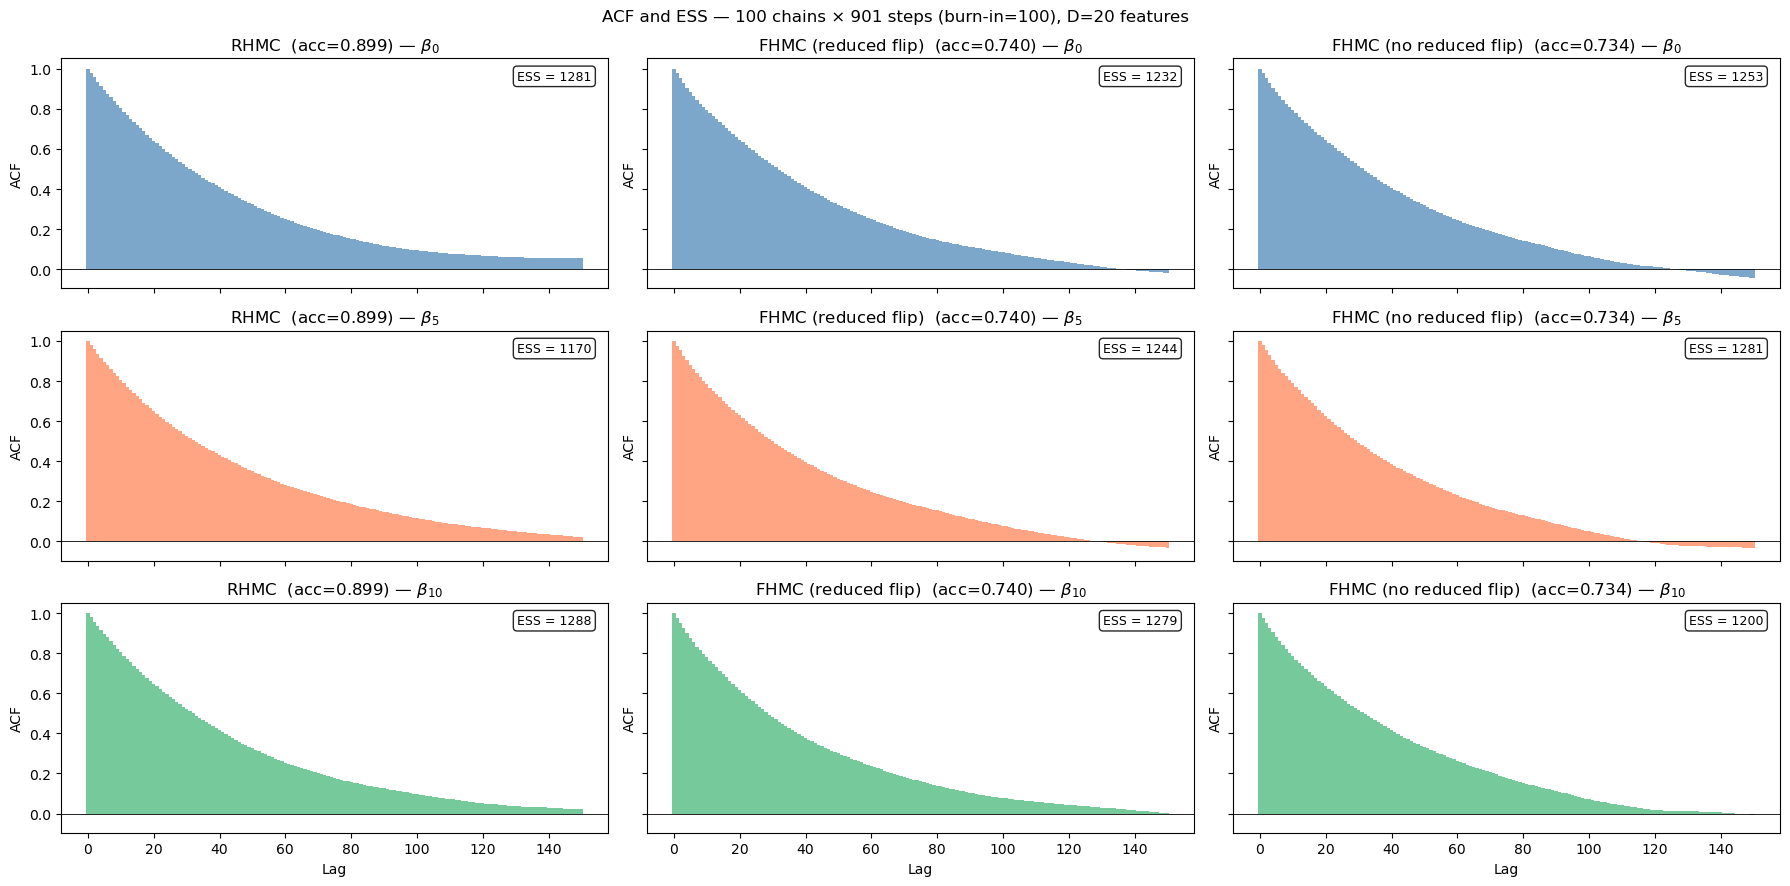

In [35]:
def acf(chain, max_lag):
    """Normalized autocorrelation at lags 0..max_lag for a 1D array."""
    chain = chain - chain.mean()
    var = np.var(chain)
    if var == 0:
        return np.ones(max_lag + 1)  # constant chain → perfect autocorrelation
    return np.array([
        np.mean(chain[:len(chain) - k] * chain[k:]) / var if k > 0 else 1.0
        for k in range(max_lag + 1)
    ])

def ess_from_chain(chain, max_lag):
    """
    ESS = N / IAT,  IAT = 1 + 2 * sum_{k>=1} ACF(k).
    Sum truncated at the first negative lag (Geyer's initial positive sequence).
    """
    ac = acf(chain, max_lag)
    first_neg = np.argmax(ac[1:] < 0)
    cutoff = first_neg if first_neg > 0 else max_lag
    iat = 1.0 + 2.0 * ac[1:cutoff + 1].sum()
    return len(chain) / max(iat, 1.0)

def mean_acf(traj, dim, max_lag):
    """Average ACF over all chains for a given coordinate dimension."""
    return np.mean([acf(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])], axis=0)

def total_ess(traj, dim, max_lag):
    """Total ESS summed over all chains for a given coordinate dimension."""
    return sum(ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0]))

def min_ess(traj, max_lag):
    """Min ESS across all dimensions, summed over chains."""
    return min(
        sum(ess_from_chain(traj[i, :, d].numpy(), max_lag) for i in range(traj.shape[0]))
        for d in range(traj.shape[2])
    )

def argmin_ess_dim(traj, max_lag):
    """Which dimension achieves the minimum ESS."""
    ess_per_dim = [
        sum(ess_from_chain(traj[i, :, d].numpy(), max_lag) for i in range(traj.shape[0]))
        for d in range(traj.shape[2])
    ]
    return int(np.argmin(ess_per_dim)), ess_per_dim

burn_in  = 100
max_lag  = 150
lags     = np.arange(max_lag + 1)

# Apply burn-in before ESS/ACF analysis
traj_rhmc_b    = traj_rhmc[:,    burn_in:, :]
traj_fhmc_b    = traj_fhmc[:,    burn_in:, :]
traj_fhmc_rf_b = traj_fhmc_rf[:, burn_in:, :]

n_chains = traj_rhmc_b.shape[0]
n_steps  = traj_rhmc_b.shape[1]
D        = traj_rhmc_b.shape[2] - 1  # number of features (excluding bias)

# ── ESS summary table ────────────────────────────────────────────────────────
print(f"{'Sampler':<28} {'min ESS':>10}  {'mean ESS':>10}  {'worst dim':>12}")
print("─" * 68)
for traj, label in [
    (traj_rhmc_b,    "RHMC"),
    (traj_fhmc_rf_b, "FHMC (reduced flip)"),
    (traj_fhmc_b,    "FHMC (no reduced flip)"),
]:
    worst_dim, ess_per_dim = argmin_ess_dim(traj, max_lag)
    mean_ess_val = np.mean(ess_per_dim)
    dim_name = rf"$\beta_{{{worst_dim}}}$"
    print(f"{label:<28} {ess_per_dim[worst_dim]:10.1f}  {mean_ess_val:10.1f}  {dim_name:>12}")

# ── ACF plots: β_0, β_5, β_10 ───────────────────────────────────────────────
plot_dims = [
    (r"$\beta_0$",    0,  "steelblue"),
    (r"$\beta_5$",    5,  "coral"),
    (r"$\beta_{10}$", 10, "mediumseagreen"),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 9), sharey=True, sharex=True)

for row, (coord_name, dim, color) in enumerate(plot_dims):
    for col, (traj, acc, label) in enumerate([
        (traj_rhmc_b,    acc_rhmc,    "RHMC"),
        (traj_fhmc_rf_b, acc_fhmc_rf, "FHMC (reduced flip)"),
        (traj_fhmc_b,    acc_fhmc,    "FHMC (no reduced flip)"),
    ]):
        ac      = mean_acf(traj, dim, max_lag)
        ess_val = total_ess(traj, dim, max_lag)
        ax      = axes[row, col]
        ax.bar(lags, ac, width=1.0, color=color, alpha=0.7)
        ax.axhline(0, color="k", linewidth=0.6)
        ax.set_title(f"{label}  (acc={acc:.3f}) — {coord_name}")
        ax.set_ylabel("ACF")
        ax.text(0.97, 0.95, f"ESS = {ess_val:.0f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

for ax in axes[2]:
    ax.set_xlabel("Lag")

plt.suptitle(
    f"ACF and ESS — {n_chains} chains × {n_steps} steps (burn-in={burn_in}), D={D} features",
    fontsize=12,
)
plt.tight_layout()
plt.show()